In [46]:
import pandas
import numpy
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import transformers
from transformers import pipeline

In [47]:
data = pandas.read_csv('book-reviews-sample.csv')

In [48]:
data.head()

,index,reviewText,rating
0,11494,Clean and funny. A bit busy with all the diffe...,3
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4
2,1463,Good thing that this is a free story. I read i...,1
3,10342,"Action, action, action! Equipment keeps gettin...",4
4,5256,this was hands down the worse book i have ever...,1


In [49]:
#not cleaning the text and removing punctuation because it might affect sentiment score

vader_sentiment = SentimentIntensityAnalyzer()
data['vader_sentiment_score'] = data['reviewText'].apply(lambda review : vader_sentiment.polarity_scores(review)['compound'])

data.head()

,index,reviewText,rating,vader_sentiment_score
0,11494,Clean and funny. A bit busy with all the diffe...,3,0.7684
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,0.9325
2,1463,Good thing that this is a free story. I read i...,1,0.6740
3,10342,"Action, action, action! Equipment keeps gettin...",4,0.6948
4,5256,this was hands down the worse book i have ever...,1,-0.4767


In [50]:
# (-1, -0.1] → 'negative' (scores from -1 to -0.1)
# (-0.1, 0.1] → 'neutral' (scores from -0.1 to 0.1)
# (0.1, 1] → 'positive' (scores from 0.1 to 1)

bins = [-1, -0.1, 0.1, 1]
names = ['negative', 'neutral', 'positive']

data['vader_sentiment_label'] = pandas.cut(data['vader_sentiment_score'], bins, labels=names)


# x: The data to bin (array-like or Series)
# bins: Number of bins OR list of bin edges
# labels: Names for the resulting categories
# right: Whether bins include the right edge (interval (] ) (default: True)

""" 
e.g.

Original data: [0.5, 1.2, 2.8, 3.1, 4.5]
Bins: [0, 2, 4]

Result:
  0.5  →  (0, 2]      ← Falls in first bin
  1.2  →  (0, 2]      ← Falls in first bin
  2.8  →  (2, 4]      ← Falls in second bin
  3.1  →  (2, 4]      ← Falls in second bin
  4.5  →  NaN         ← Outside all bins!
"""

data.head()

,index,reviewText,rating,vader_sentiment_score,vader_sentiment_label
0,11494,Clean and funny. A bit busy with all the diffe...,3,0.7684,positive
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,0.9325,positive
2,1463,Good thing that this is a free story. I read i...,1,0.6740,positive
3,10342,"Action, action, action! Equipment keeps gettin...",4,0.6948,positive
4,5256,this was hands down the worse book i have ever...,1,-0.4767,negative


<Axes: xlabel='vader_sentiment_label'>

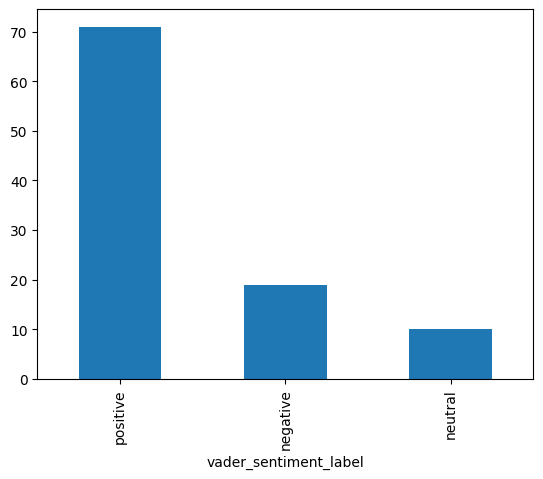

In [51]:
data['vader_sentiment_label'].value_counts().plot.bar()

In [52]:
transformers_ppline = pipeline('sentiment-analysis', model='finiteautomata/bertweet-base-sentiment-analysis')


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
Device set to use cpu


In [ ]:
transformers_labels = []
for review in data['reviewText'].values: #u don't need to use '.values' explicitly writing for clarity, without .values, pandas returns a series, but still automatically extracts values.
    sentiment_list = transformers_ppline(review)  
    # sentiment_label = [val['label'] for val in sentiment_list]
    # transformers_labels.append(sentiment_label[0])
    transformers_labels.append(sentiment_list[0]['label'])

data['transformers_sentiment_label'] = transformers_labels

<Axes: xlabel='transformers_sentiment_label'>

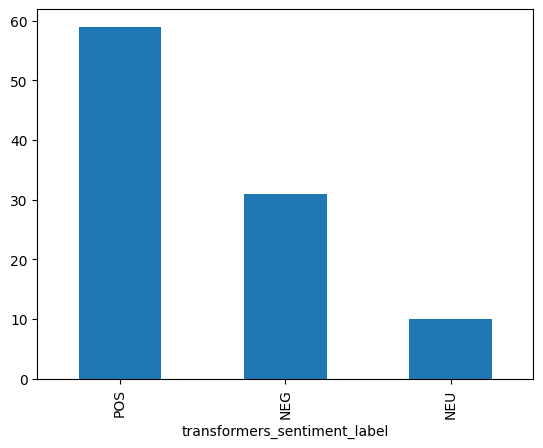

In [54]:
data['transformers_sentiment_label'].value_counts().plot.bar()

In [55]:
data['transformers_sentiment_label'].head()

0    POS
1    POS
2    NEG
3    POS
4    NEG
Name: transformers_sentiment_label, dtype: object